# Try Next: Fixing Noisy Blowup — 50 Rollouts, 500 Epochs

Implements the checklist from `results/2026-03-09/try_next.md`.

**Root cause:** Massive undertraining (~1000 gradient steps vs SOPE's 500k).

| Parameter | Mar 9 notebook | This notebook |
|-----------|--------------|--------------|
| Offline rollouts | 50 | 50 (reuse cached) |
| Training epochs | 50 | 500 |
| Gradient steps | ~850 | ~8,500 |
| LR scheduler | None | CosineAnnealingLR |
| Checkpoints saved | final only | 50, 100, 200, 500 |
| Diffusion steps | 256 | 256 |

**Phases implemented:**
1. **Phase 1.1–1.3**: Scale training, log loss curves, compare to SOPE reference
2. **Phase 2.2**: Single-chunk quality check (no stitching)
3. **Phase 3.1**: Normalization round-trip verification
4. **Phase 3.2**: Per-step MSE during stitching
5. **Phase 3.3**: Clamped-output baseline

**Note on Phase 2.1 (diffusion step count):** SOPE's `GaussianDiffusion` bakes `n_timesteps` into the noise schedule at init. Changing steps at inference requires retraining. Deferred to a follow-up experiment.

## Phase 1.3: SOPE Reference Training Budget

From `third_party/sope/opelab/examples/d4rl/diffusion_trainer.py` and configs:

| Parameter | SOPE Reference | Our Mar 9 | This Notebook |
|-----------|---------------|-----------|---------------|
| Epochs | 100 | 50 | 500 |
| Steps/epoch | 5000 (with replacement) | ~17 (1 pass) | ~17 (1 pass) |
| **Total gradient steps** | **500,000** | **~850** | **~8,500** |
| Batch size | 128 | 64 | 64 |
| LR | 3e-4 | 3e-4 | 3e-4 |
| LR scheduler | CosineAnnealingLR | None | CosineAnnealingLR |
| Diffusion steps (D) | 256 | 256 | 256 |
| Chunk horizon (T) | 4–8 | 8 | 8 |

**Key insight:** SOPE samples 5000 batches *with replacement* per epoch (not 1 pass through the dataset). With our ~1250 chunks, each "epoch" resamples the data ~250 times. Our 500-epoch run with 17 batches/epoch gives ~8500 steps — still 60x fewer than SOPE, but a 10x improvement over yesterday. If 500 epochs shows convergence, the model may still work. If not, we need to add with-replacement sampling.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import torch

# Two levels up from experiments/2026-03-10/
REPO_ROOT = Path("../../").resolve()
sys.path.insert(0, str(REPO_ROOT))

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Repo root: {REPO_ROOT}")

# --- Common paths ---
POLICY_DIR = REPO_ROOT / "third_party" / "robomimic" / "diffusion_policy_trained_models" / "test"
policy_train_dirs = sorted([d for d in POLICY_DIR.glob("*") if d.is_dir()])
assert len(policy_train_dirs) > 0, "No trained policies found."
policy_train_dir = policy_train_dirs[-1]
print(f"Using policy from: {policy_train_dir}")

# --- Common hyperparams ---
K = 50             # oracle rollouts (reuse cached)
N_ROLLOUTS = 50    # offline rollouts (reuse cached)
EPOCHS = 500       # diffusion training epochs (10x increase)
HORIZON = 60
gamma = 1.0
BATCH_SIZE = 64
NUM_TRAJS = 50     # synthetic trajectories
obs_keys = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]

# Checkpoints to save during training
CHECKPOINT_EPOCHS = [50, 100, 200, 500]

Device: cuda
Repo root: /home1/reishuen/latent_sope
Using policy from: /home1/reishuen/latent_sope/third_party/robomimic/diffusion_policy_trained_models/test/20260309132349


## Step 0: Ground Truth (Oracle Baseline)

Reuse cached oracle from Mar 9.

In [2]:
import json

from src.latent_sope.robomimic_interface.checkpoints import load_checkpoint
from src.latent_sope.eval.oracle import oracle_value as compute_oracle_value, save_oracle_result, load_oracle_result

oracle_path = policy_train_dir / "oracle_50.json"
assert oracle_path.exists(), f"Oracle cache not found at {oracle_path}. Run the Mar 9 notebook first."

oracle_result = load_oracle_result(oracle_path)
oracle_value = oracle_result.mean_return
oracle_returns = oracle_result.returns.tolist()
print(f"Loaded cached oracle from {oracle_path}")
print(f"  Oracle V^pi = {oracle_value:.3f} (std={np.std(oracle_returns):.3f}, K={len(oracle_returns)})")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.l

Loaded cached oracle from /home1/reishuen/latent_sope/third_party/robomimic/diffusion_policy_trained_models/test/20260309132349/oracle_50.json
  Oracle V^pi = 0.540 (std=0.498, K=50)


## Step 1: Collect Offline Data (cached)

In [3]:
from src.latent_sope.robomimic_interface.rollout import (
    save_rollout_latents,
    load_rollout_latents,
    get_policy_frame_stack,
    PolicyFeatureHook,
    RolloutLatentRecorder,
)
from src.latent_sope.robomimic_interface.collect import collect_rollouts

output_dir = policy_train_dir / "rollout_latents_50"
existing_rollouts = sorted(output_dir.glob("*.h5"))
assert len(existing_rollouts) >= N_ROLLOUTS, (
    f"Only {len(existing_rollouts)} rollouts found in {output_dir}. "
    f"Need {N_ROLLOUTS}. Run the Mar 9 notebook first."
)
rollout_paths = existing_rollouts[:N_ROLLOUTS]
print(f"Using {len(rollout_paths)} cached rollout files from {output_dir}")

Using 50 cached rollout files from /home1/reishuen/latent_sope/third_party/robomimic/diffusion_policy_trained_models/test/20260309132349/rollout_latents_50


## Step 2: Chunk the Offline Data

In [4]:
from src.latent_sope.robomimic_interface.dataset import (
    RolloutChunkDatasetConfig,
    make_rollout_chunk_dataloader,
)

sample_traj = load_rollout_latents(rollout_paths[0])
latents_dim = sample_traj.latents.shape[-1]
action_dim = sample_traj.actions.shape[-1]
print(f"Latent dim: {latents_dim}, Action dim: {action_dim}")

dataset_config = RolloutChunkDatasetConfig(
    chunk_size=8,
    stride=2,
    frame_stack=2,
    source="latents",
    latents_dim=latents_dim,
    action_dim=action_dim,
    normalize=True,
    return_metadata=True,
)

dataloader, norm_stats = make_rollout_chunk_dataloader(
    paths=rollout_paths,
    config=dataset_config,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)

n_batches = len(dataloader)
total_steps = n_batches * EPOCHS
print(f"DataLoader: {n_batches} batches of size {BATCH_SIZE}")
print(f"Total gradient steps over {EPOCHS} epochs: {total_steps}")
print(f"Normalization stats: mean shape={norm_stats.mean.shape}")

Latent dim: 19, Action dim: 7
DataLoader: 17 batches of size 64
Total gradient steps over 500 epochs: 8500
Normalization stats: mean shape=(26,)


## Phase 1.1 + 1.2: Train 500 Epochs with Loss Logging

Key changes from Mar 9:
- 500 epochs (was 50) → ~8500 gradient steps (was ~850)
- CosineAnnealingLR scheduler (matching SOPE reference)
- Save checkpoints at epochs 50, 100, 200, 500
- Log mean loss every epoch

In [5]:
from tqdm.auto import tqdm
from dataclasses import asdict
import matplotlib.pyplot as plt
from src.latent_sope.diffusion.sope_diffuser import (
    SopeDiffusionConfig,
    SopeDiffuser,
    NormalizationStats as DiffusionNormStats,
    cross_validate_configs,
)

# Checkpoint directory for this experiment
ckpt_dir = policy_train_dir / "diffusion_ckpts_50_500ep"
ckpt_dir.mkdir(exist_ok=True)

diffusion_config = SopeDiffusionConfig(
    chunk_horizon=dataset_config.chunk_size,
    frame_stack=dataset_config.frame_stack,
    state_dim=latents_dim,
    action_dim=action_dim,
    diffusion_steps=256,
    dim_mults=(1, 2),
    attention=False,
    loss_type="l2",
    action_weight=5.0,
    predict_epsilon=True,
    lr=3e-4,
    guided=False,
)

cross_validate_configs(dataset_config, diffusion_config)
print("Config cross-validation passed.")

diff_norm_stats = None
if norm_stats is not None:
    diff_norm_stats = DiffusionNormStats(mean=norm_stats.mean, std=norm_stats.std)

diffuser = SopeDiffuser(cfg=diffusion_config, normalization_stats=diff_norm_stats, device=device)
optimizer = diffuser.make_optimizer()

# CosineAnnealingLR like SOPE reference (T_max = 2 * epochs)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=2 * EPOCHS)

n_params = sum(p.numel() for p in diffuser.diffusion.parameters())
print(f"TemporalUnet parameters: {n_params:,}")
print(f"Training for {EPOCHS} epochs (~{n_batches * EPOCHS} gradient steps)...")
print(f"Checkpoints will be saved at epochs: {CHECKPOINT_EPOCHS}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Config cross-validation passed.
[ models/temporal ] Channel dimensions: [(26, 32), (32, 64)]
[(26, 32), (32, 64)]
TemporalUnet parameters: 252,698
Training for 500 epochs (~8500 gradient steps)...
Checkpoints will be saved at epochs: [50, 100, 200, 500]


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


In [6]:
# --- Training loop ---
GRAD_CLIP = 1.0
all_losses = []        # per-step losses
epoch_mean_losses = []  # per-epoch mean loss
lr_history = []         # track LR schedule

diffuser.diffusion.train()

for epoch in range(1, EPOCHS + 1):
    epoch_losses = []
    for batch in tqdm(dataloader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False):
        batch_dev = {
            k: v.to(device) if isinstance(v, torch.Tensor) else v
            for k, v in batch.items()
        }
        loss, info = diffuser.loss(batch_dev)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(diffuser.diffusion.parameters(), GRAD_CLIP)
        optimizer.step()
        all_losses.append(loss.item())
        epoch_losses.append(loss.item())

    scheduler.step()
    mean_loss = np.mean(epoch_losses)
    epoch_mean_losses.append(mean_loss)
    lr_history.append(scheduler.get_last_lr()[0])

    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}: mean loss = {mean_loss:.6f}, lr = {lr_history[-1]:.2e}")

    # Save checkpoints at specified epochs
    if epoch in CHECKPOINT_EPOCHS:
        ckpt_payload = {
            "diffusion_state_dict": diffuser.diffusion.state_dict(),
            "epoch": epoch,
            "step": len(all_losses),
            "mean_loss": mean_loss,
            "diffusion_config": asdict(diffusion_config),
            "dataset_config": asdict(dataset_config),
            "normalization_stats": {
                "mean": norm_stats.mean, "std": norm_stats.std,
            } if norm_stats is not None else None,
        }
        save_path = ckpt_dir / f"sope_diffuser_epoch_{epoch:04d}.pt"
        torch.save(ckpt_payload, str(save_path))
        print(f"  -> Saved checkpoint to {save_path.name}")

# Also save as "latest"
ckpt_payload["epoch"] = EPOCHS
ckpt_payload["step"] = len(all_losses)
ckpt_payload["mean_loss"] = epoch_mean_losses[-1]
torch.save(ckpt_payload, str(ckpt_dir / "sope_diffuser_latest.pt"))
print(f"\nTraining complete. Final loss: {epoch_mean_losses[-1]:.6f}")
print(f"Total gradient steps: {len(all_losses)}")

Epoch 1/500:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch    1: mean loss = 1.339690, lr = 3.00e-04


Epoch 2/500:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 3/500:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 4/500:   0%|          | 0/17 [00:00<?, ?it/s]

...

Epoch 497/500:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 498/500:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 499/500:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch 500/500:   0%|          | 0/17 [00:00<?, ?it/s]

Epoch  500: mean loss = 0.728080, lr = 1.50e-04
  -> Saved checkpoint to sope_diffuser_epoch_0500.pt

Training complete. Final loss: 0.728080
Total gradient steps: 8500


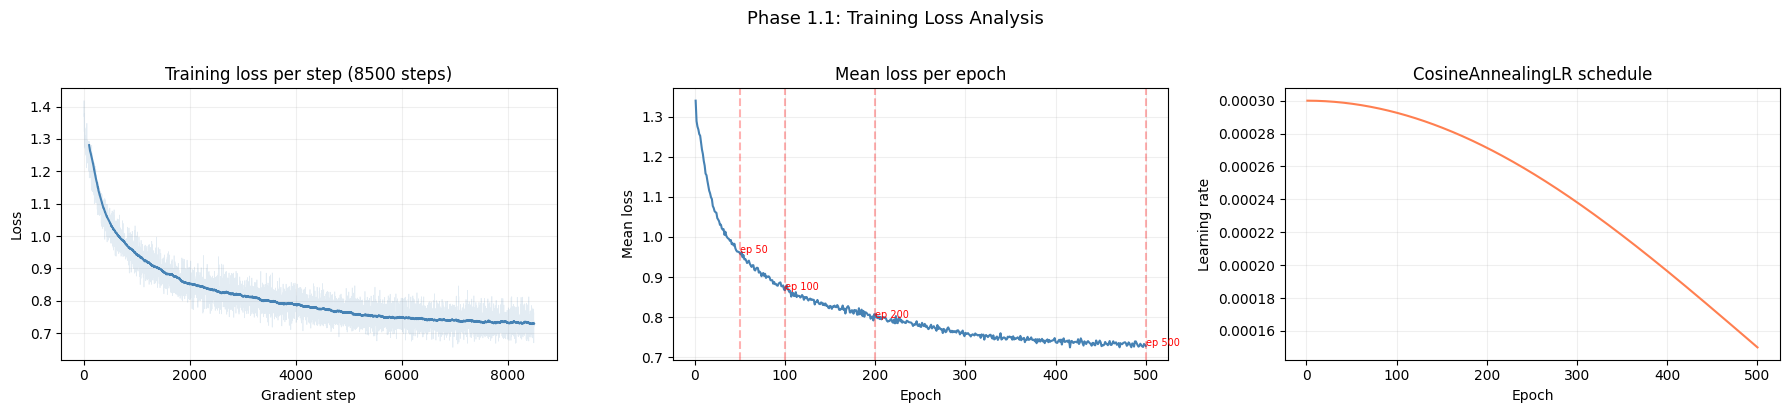


Convergence check:
  First 10% epochs mean loss:  1.079874
  Last 10% epochs mean loss:   0.732554
  Ratio (last/first):          0.6784
  -> Loss may have plateaued or is still decreasing slowly.


In [7]:
# --- Phase 1.1: Loss curve analysis ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Raw loss per step (smoothed)
ax = axes[0]
ax.plot(all_losses, alpha=0.15, color="steelblue", linewidth=0.5)
window = min(100, max(1, len(all_losses) // 10))
if window > 1:
    smoothed = np.convolve(all_losses, np.ones(window) / window, mode="valid")
    ax.plot(range(window - 1, len(all_losses)), smoothed, color="steelblue", linewidth=1.5)
ax.set_xlabel("Gradient step")
ax.set_ylabel("Loss")
ax.set_title(f"Training loss per step ({len(all_losses)} steps)")
ax.grid(alpha=0.2)

# 2. Mean loss per epoch
ax = axes[1]
ax.plot(range(1, EPOCHS + 1), epoch_mean_losses, color="steelblue", linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean loss")
ax.set_title("Mean loss per epoch")
ax.grid(alpha=0.2)
# Mark checkpoint epochs
for ep in CHECKPOINT_EPOCHS:
    if ep <= len(epoch_mean_losses):
        ax.axvline(ep, color="red", alpha=0.3, linestyle="--")
        ax.annotate(f"ep {ep}", (ep, epoch_mean_losses[ep - 1]), fontsize=7, color="red")

# 3. LR schedule
ax = axes[2]
ax.plot(range(1, EPOCHS + 1), lr_history, color="coral", linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning rate")
ax.set_title("CosineAnnealingLR schedule")
ax.grid(alpha=0.2)

fig.suptitle("Phase 1.1: Training Loss Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Convergence check
last_10pct = epoch_mean_losses[int(0.9 * EPOCHS):]
first_10pct = epoch_mean_losses[:int(0.1 * EPOCHS)]
print(f"\nConvergence check:")
print(f"  First 10% epochs mean loss:  {np.mean(first_10pct):.6f}")
print(f"  Last 10% epochs mean loss:   {np.mean(last_10pct):.6f}")
print(f"  Ratio (last/first):          {np.mean(last_10pct) / np.mean(first_10pct):.4f}")
if np.mean(last_10pct) < 0.5 * np.mean(first_10pct):
    print("  -> Loss decreased significantly. Model is learning.")
else:
    print("  -> Loss may have plateaued or is still decreasing slowly.")

## Phase 3.1: Normalization Round-Trip Verification

Verify that `normalize → unnormalize` is lossless on training data.

In [8]:
# --- Phase 3.1: Normalization round-trip ---
test_batch = next(iter(dataloader))
test_batch_dev = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in test_batch.items()}

# Build a chunk from the batch (same format as training)
cat_sf = torch.cat([test_batch_dev["states_from"], test_batch_dev["actions_from"]], dim=-1)
cat_st = torch.cat([test_batch_dev["states_to"][:, :-1, :], test_batch_dev["actions_to"]], dim=-1)
x_normalized = torch.cat([cat_sf, cat_st], dim=1)  # (B, total_horizon, transition_dim)

# Round-trip: unnormalize then re-normalize
x_unnorm = diffuser.unnormalizer(x_normalized)
x_renorm = diffuser.normalizer(x_unnorm)

# Compare
roundtrip_error = (x_normalized - x_renorm).abs()
print("Normalization round-trip (normalize → unnormalize → re-normalize):")
print(f"  Max absolute error:  {roundtrip_error.max().item():.2e}")
print(f"  Mean absolute error: {roundtrip_error.mean().item():.2e}")
print(f"  Relative error (vs data range): {roundtrip_error.max().item() / x_normalized.abs().max().item():.2e}")

if roundtrip_error.max().item() < 1e-5:
    print("  -> Round-trip is essentially lossless. Normalization is NOT the problem.")
else:
    print("  -> WARNING: Non-trivial round-trip error! Investigate normalization implementation.")

Normalization round-trip (normalize → unnormalize → re-normalize):
  Max absolute error:  2.38e-07
  Mean absolute error: 1.93e-09
  Relative error (vs data range): 1.92e-08
  -> Round-trip is essentially lossless. Normalization is NOT the problem.


## Phase 2.2: Single-Chunk Quality at Each Checkpoint

Evaluate chunk reconstruction L2 at epochs 50, 100, 200, 500 to see quality progression.
**Target:** chunk L2 < 1.0 before attempting stitching.

In [9]:
from src.latent_sope.eval.metrics import l2_chunk_error

# Grab a test batch for evaluation
test_batch = next(iter(dataloader))
test_batch_dev = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in test_batch.items()}

# Build ground-truth normalized chunks
cat_sf = torch.cat([test_batch_dev["states_from"], test_batch_dev["actions_from"]], dim=-1)
cat_st = torch.cat([test_batch_dev["states_to"][:, :-1, :], test_batch_dev["actions_to"]], dim=-1)
x_gt = torch.cat([cat_sf, cat_st], dim=1)
cond = diffuser.make_cond(test_batch_dev)

state_dim = diffuser.state_dim

# Evaluate each checkpoint
chunk_results = {}

for ckpt_epoch in CHECKPOINT_EPOCHS:
    ckpt_file = ckpt_dir / f"sope_diffuser_epoch_{ckpt_epoch:04d}.pt"
    if not ckpt_file.exists():
        print(f"Checkpoint epoch {ckpt_epoch} not found, skipping.")
        continue

    # Load checkpoint weights
    payload = torch.load(str(ckpt_file), map_location=device, weights_only=False)
    diffuser.diffusion.load_state_dict(payload["diffusion_state_dict"])
    diffuser.diffusion.eval()

    # Denoise from noise
    with torch.no_grad():
        sample = diffuser.diffusion.conditional_sample(
            shape=x_gt.shape, cond=cond, guided=False, verbose=False,
        )
    x_hat = sample.trajectories

    # Unnormalize for comparison
    x_gt_unnorm = diffuser.unnormalizer(x_gt).cpu().numpy()
    x_hat_unnorm = diffuser.unnormalizer(x_hat).cpu().numpy()

    err_s = l2_chunk_error(x_hat_unnorm[:, :, :state_dim], x_gt_unnorm[:, :, :state_dim])
    err_a = l2_chunk_error(x_hat_unnorm[:, :, state_dim:], x_gt_unnorm[:, :, state_dim:])

    chunk_results[ckpt_epoch] = {
        "state_l2": err_s.mean_l2,
        "state_l2_std": err_s.std_l2,
        "action_l2": err_a.mean_l2,
        "action_l2_std": err_a.std_l2,
        "rmse_per_dim": err_s.rmse_per_dim,
    }
    print(f"Epoch {ckpt_epoch:4d}: state L2 = {err_s.mean_l2:.4f} ± {err_s.std_l2:.4f}, "
          f"action L2 = {err_a.mean_l2:.4f} ± {err_a.std_l2:.4f}")

# Reload final checkpoint for subsequent steps
best_epoch = CHECKPOINT_EPOCHS[-1]
payload = torch.load(str(ckpt_dir / f"sope_diffuser_epoch_{best_epoch:04d}.pt"), map_location=device, weights_only=False)
diffuser.diffusion.load_state_dict(payload["diffusion_state_dict"])
diffuser.diffusion.eval()
print(f"\nLoaded epoch {best_epoch} checkpoint for subsequent steps.")


                                                                                                    
1 / 256 [                                                            ]   0% | 20.2 Hz
t : 255
                                                                                                    
                                                                                                    
2 / 256 [                                                            ]   0% | 35.6 Hz
t : 254
                                                                                                    
                                                                                                    
3 / 256 [                                                            ]   1% | 48.9 Hz
t : 253
                                                                                                    
                                                                                                    
4 / 256 [ 

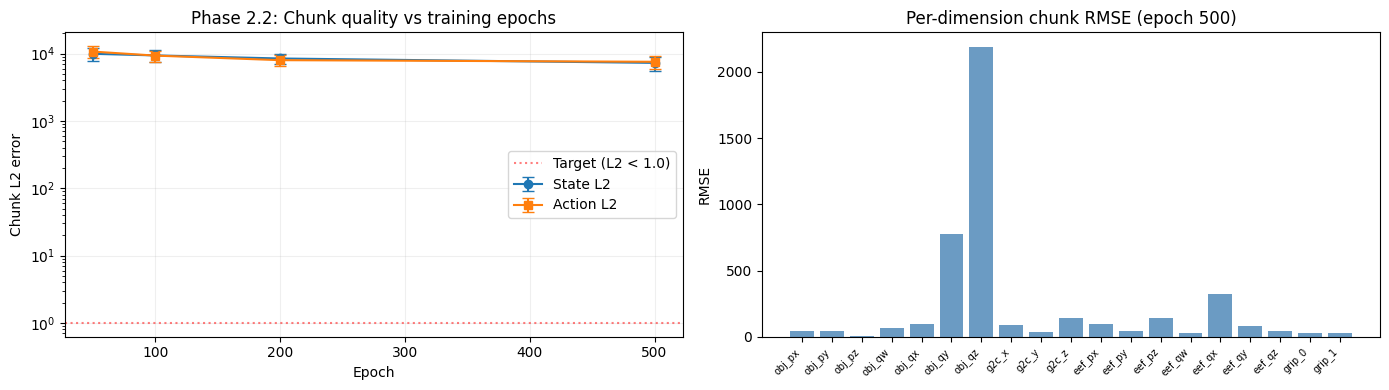


Final chunk L2 (states): 7287.4297
FAIL: Chunk quality still poor. Consider more training or architectural changes.


In [10]:
# --- Visualize chunk quality progression ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

epochs_list = sorted(chunk_results.keys())
state_l2s = [chunk_results[e]["state_l2"] for e in epochs_list]
action_l2s = [chunk_results[e]["action_l2"] for e in epochs_list]
state_stds = [chunk_results[e]["state_l2_std"] for e in epochs_list]
action_stds = [chunk_results[e]["action_l2_std"] for e in epochs_list]

# 1. L2 vs epoch
ax = axes[0]
ax.errorbar(epochs_list, state_l2s, yerr=state_stds, marker="o", label="State L2", capsize=4)
ax.errorbar(epochs_list, action_l2s, yerr=action_stds, marker="s", label="Action L2", capsize=4)
ax.axhline(1.0, color="red", linestyle=":", alpha=0.5, label="Target (L2 < 1.0)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Chunk L2 error")
ax.set_title("Phase 2.2: Chunk quality vs training epochs")
ax.legend()
ax.set_yscale("log")
ax.grid(alpha=0.2)

# 2. Per-dimension RMSE at final checkpoint
ax = axes[1]
dim_labels = [
    "obj_px", "obj_py", "obj_pz", "obj_qw", "obj_qx", "obj_qy", "obj_qz",
    "g2c_x", "g2c_y", "g2c_z", "eef_px", "eef_py", "eef_pz",
    "eef_qw", "eef_qx", "eef_qy", "eef_qz", "grip_0", "grip_1",
]
final_rmse = chunk_results[epochs_list[-1]]["rmse_per_dim"]
ax.bar(range(len(final_rmse)), final_rmse, color="steelblue", alpha=0.8)
ax.set_xticks(range(len(dim_labels)))
ax.set_xticklabels(dim_labels, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("RMSE")
ax.set_title(f"Per-dimension chunk RMSE (epoch {epochs_list[-1]})")

plt.tight_layout()
plt.show()

# Decision gate
final_l2 = chunk_results[epochs_list[-1]]["state_l2"]
print(f"\nFinal chunk L2 (states): {final_l2:.4f}")
if final_l2 < 1.0:
    print("PASS: Chunk quality meets target. Proceeding to stitching.")
elif final_l2 < 10.0:
    print("MARGINAL: Chunk quality improved but still above target. Stitching may be noisy.")
else:
    print("FAIL: Chunk quality still poor. Consider more training or architectural changes.")

## Step 5: Generate Synthetic Trajectories via Stitching

In [11]:
NUM_TRAJS = 50
MAX_LENGTH = HORIZON

# Sample initial states from offline rollouts
init_states = []
for i in range(NUM_TRAJS):
    traj_i = load_rollout_latents(rollout_paths[i % len(rollout_paths)])
    latents = traj_i.latents
    if latents.ndim == 3:
        latents = latents[:, 0, :]
    init_states.append(latents[0])

init_states_t = torch.tensor(np.stack(init_states), dtype=torch.float32)

print(f"Generating {NUM_TRAJS} stitched trajectories (max {MAX_LENGTH} steps)...\n")

syn_states, syn_actions, end_indices = diffuser.generate_full_trajectory(
    initial_states=init_states_t,
    max_length=MAX_LENGTH,
    guided=False,
    verbose=False,
)

print(f"Generated {NUM_TRAJS} trajectories:")
print(f"  states shape: {syn_states.shape}")
print(f"  actions shape: {syn_actions.shape}")
print(f"  state range: [{syn_states.min():.2f}, {syn_states.max():.2f}]")
print(f"  action range: [{syn_actions.min():.2f}, {syn_actions.max():.2f}]")

Generating 50 stitched trajectories (max 60 steps)...


                                                                                                    
1 / 256 [                                                            ]   0% | 69.8 Hz
t : 255
                                                                                                    
                                                                                                    
2 / 256 [                                                            ]   0% | 102.6 Hz
t : 254
                                                                                                    
                                                                                                    
3 / 256 [                                                            ]   1% | 123.0 Hz
t : 253
                                                                                                    
                                                      

## Phase 3.2: Per-Step MSE During Stitching

Compare real vs synthetic at each timestep to see error accumulation from autoregressive drift.

In [12]:
from src.latent_sope.eval.metrics import trajectory_reconstruction_mse

# Load real trajectories (matching init states used for generation)
real_states_list, real_actions_list, real_rewards_list = [], [], []
for i in range(NUM_TRAJS):
    traj_i = load_rollout_latents(rollout_paths[i % len(rollout_paths)])
    latents = traj_i.latents
    if latents.ndim == 3:
        latents = latents[:, 0, :]
    actions, rewards = traj_i.actions, traj_i.rewards
    T = latents.shape[0]
    if T >= MAX_LENGTH:
        real_states_list.append(latents[:MAX_LENGTH])
        real_actions_list.append(actions[:MAX_LENGTH])
        real_rewards_list.append(rewards[:MAX_LENGTH])
    else:
        real_states_list.append(np.pad(latents, ((0, MAX_LENGTH - T), (0, 0))))
        real_actions_list.append(np.pad(actions, ((0, MAX_LENGTH - T), (0, 0))))
        real_rewards_list.append(np.pad(rewards, (0, MAX_LENGTH - T)))

real_states = np.stack(real_states_list).astype(np.float32)
real_actions = np.stack(real_actions_list).astype(np.float32)
real_rewards = np.stack(real_rewards_list).astype(np.float32)

recon = trajectory_reconstruction_mse(real_states, syn_states, real_actions, syn_actions, end_indices)
print(f"Trajectory Reconstruction MSE ({recon.num_trajectories} trajs, {recon.trajectory_length} steps):")
print(f"  State MSE:  {recon.state_mse:.6f}")
print(f"  Action MSE: {recon.action_mse:.6f}")

Trajectory Reconstruction MSE (50 trajs, 60 steps):
  State MSE:  1175015.064702
  Action MSE: 4163262.561524


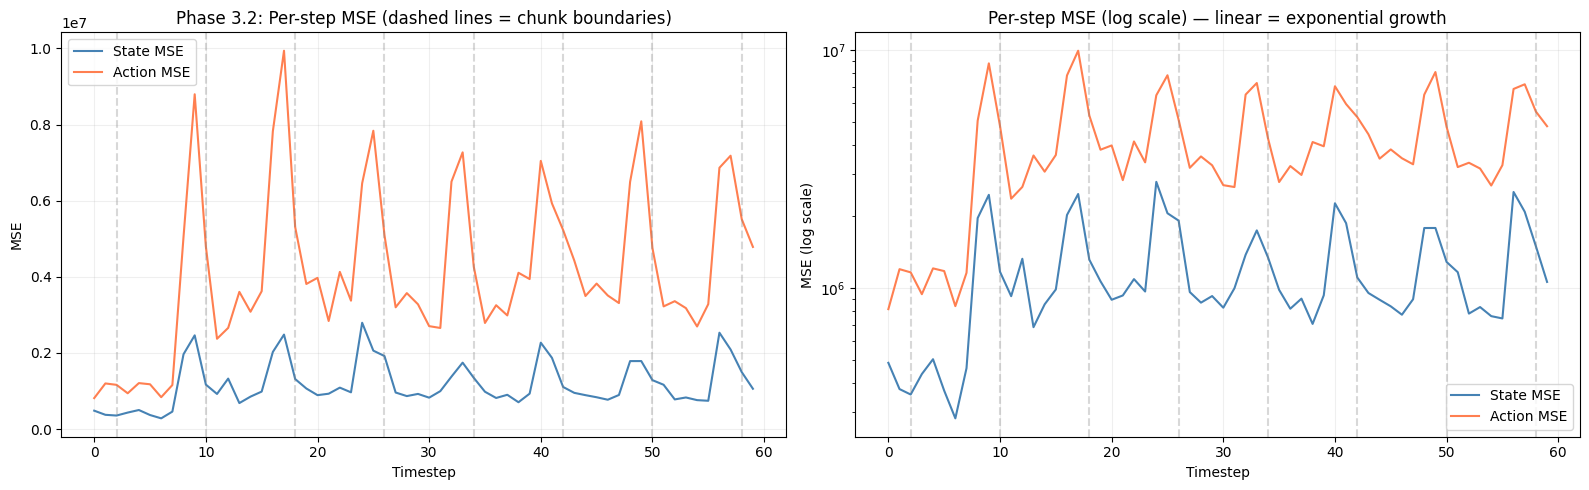

Error growth: 3.2x total over 7 chunks
  Per-chunk growth factor: 1.21x
  -> Moderate error growth. Stitching adds noise but may be usable.


In [13]:
# --- Phase 3.2: Per-step MSE plot with chunk boundaries ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Per-step MSE with stitching boundaries
ax = axes[0]
ax.plot(recon.state_mse_per_step, color="steelblue", linewidth=1.5, label="State MSE")
ax.plot(recon.action_mse_per_step, color="coral", linewidth=1.5, label="Action MSE")

# Mark chunk boundaries (every chunk_size=8 steps, offset by frame_stack=2)
chunk_size = diffusion_config.chunk_horizon
frame_stack = diffusion_config.frame_stack
for boundary in range(frame_stack, MAX_LENGTH, chunk_size):
    ax.axvline(boundary, color="gray", alpha=0.3, linestyle="--")
ax.set_xlabel("Timestep")
ax.set_ylabel("MSE")
ax.set_title("Phase 3.2: Per-step MSE (dashed lines = chunk boundaries)")
ax.legend()
ax.grid(alpha=0.2)

# 2. Log-scale to see exponential growth pattern
ax = axes[1]
# Avoid log(0) by clipping
state_mse_clipped = np.clip(recon.state_mse_per_step, 1e-10, None)
action_mse_clipped = np.clip(recon.action_mse_per_step, 1e-10, None)
ax.semilogy(state_mse_clipped, color="steelblue", linewidth=1.5, label="State MSE")
ax.semilogy(action_mse_clipped, color="coral", linewidth=1.5, label="Action MSE")
for boundary in range(frame_stack, MAX_LENGTH, chunk_size):
    ax.axvline(boundary, color="gray", alpha=0.3, linestyle="--")
ax.set_xlabel("Timestep")
ax.set_ylabel("MSE (log scale)")
ax.set_title("Per-step MSE (log scale) — linear = exponential growth")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Compute growth rate
if len(recon.state_mse_per_step) > 10:
    first_chunk_mse = np.mean(recon.state_mse_per_step[:chunk_size])
    last_chunk_mse = np.mean(recon.state_mse_per_step[-chunk_size:])
    n_chunks = MAX_LENGTH // chunk_size
    if first_chunk_mse > 0:
        growth_factor = last_chunk_mse / first_chunk_mse
        per_chunk_growth = growth_factor ** (1.0 / max(n_chunks - 1, 1))
        print(f"Error growth: {growth_factor:.1f}x total over {n_chunks} chunks")
        print(f"  Per-chunk growth factor: {per_chunk_growth:.2f}x")
        if per_chunk_growth > 2.0:
            print("  -> Exponential blowup. Stitching amplifies errors significantly.")
        elif per_chunk_growth > 1.2:
            print("  -> Moderate error growth. Stitching adds noise but may be usable.")
        else:
            print("  -> Error growth is controlled. Stitching is working well.")

## Phase 3.3: Clamped-Output Baseline

Clamp all synthetic states to the training data's per-dimension [min, max] range.
This tests whether the OPE pipeline works *if* the diffusion model stayed in-distribution.

In [14]:
# --- Phase 3.3: Clamped-output baseline ---

# Compute per-dimension min/max from real data
real_state_min = real_states.min(axis=(0, 1))  # (state_dim,)
real_state_max = real_states.max(axis=(0, 1))
real_action_min = real_actions.min(axis=(0, 1))
real_action_max = real_actions.max(axis=(0, 1))

# Clamp synthetic outputs
syn_states_clamped = np.clip(syn_states, real_state_min, real_state_max)
syn_actions_clamped = np.clip(syn_actions, real_action_min, real_action_max)

print("Clamping synthetic outputs to real data range:")
print(f"  Original state range:  [{syn_states.min():.2f}, {syn_states.max():.2f}]")
print(f"  Clamped state range:   [{syn_states_clamped.min():.2f}, {syn_states_clamped.max():.2f}]")
print(f"  Real state range:      [{real_states.min():.2f}, {real_states.max():.2f}]")

# How many values were clamped?
n_clamped_states = ((syn_states < real_state_min) | (syn_states > real_state_max)).sum()
n_total_states = syn_states.size
print(f"  Clamped {n_clamped_states}/{n_total_states} state values ({100*n_clamped_states/n_total_states:.1f}%)")

Clamping synthetic outputs to real data range:
  Original state range:  [-17280.18, 14051.20]
  Clamped state range:   [-1.00, 1.04]
  Real state range:      [-1.00, 1.04]
  Clamped 56837/57000 state values (99.7%)


In [15]:
# --- Score clamped trajectories and compare OPE ---
from src.latent_sope.eval.reward_model import LiftRewardFn, score_trajectories_gt, make_lift_encoder
from src.latent_sope.eval.metrics import ope_eval

encoder = make_lift_encoder(obs_keys=obs_keys)
reward_fn = LiftRewardFn(table_height=0.8, height_threshold=0.04)

# Score unclamped
returns_unclamped, rewards_unclamped = score_trajectories_gt(
    reward_fn=reward_fn, encoder=encoder,
    states=syn_states, actions=syn_actions, gamma=gamma,
)
ope_unclamped = ope_eval(oracle_value, returns_unclamped)

# Score clamped
returns_clamped, rewards_clamped = score_trajectories_gt(
    reward_fn=reward_fn, encoder=encoder,
    states=syn_states_clamped, actions=syn_actions_clamped, gamma=gamma,
)
ope_clamped = ope_eval(oracle_value, returns_clamped)

print(f"{'':30s} {'Unclamped':>12s} {'Clamped':>12s} {'Oracle':>12s}")
print("-" * 70)
print(f"{'OPE estimate':30s} {ope_unclamped.ope_estimate:12.3f} {ope_clamped.ope_estimate:12.3f} {oracle_value:12.3f}")
print(f"{'OPE std':30s} {ope_unclamped.ope_std:12.3f} {ope_clamped.ope_std:12.3f} {'':>12s}")
print(f"{'Relative error':30s} {ope_unclamped.relative_error:11.1%} {ope_clamped.relative_error:11.1%} {'':>12s}")
print(f"{'MSE':30s} {ope_unclamped.mse:12.6f} {ope_clamped.mse:12.6f} {'':>12s}")

# Success rates
real_success_rate = np.mean([float((real_states[i, :, 2] > 0.84).any()) for i in range(NUM_TRAJS)])
syn_success_unclamped = np.mean([float((syn_states[i, :, 2] > 0.84).any()) for i in range(NUM_TRAJS)])
syn_success_clamped = np.mean([float((syn_states_clamped[i, :, 2] > 0.84).any()) for i in range(NUM_TRAJS)])

print(f"\n{'Success rate (real)':30s} {real_success_rate:11.1%}")
print(f"{'Success rate (unclamped)':30s} {syn_success_unclamped:11.1%}")
print(f"{'Success rate (clamped)':30s} {syn_success_clamped:11.1%}")

if ope_clamped.relative_error < 1.0:
    print("\n-> Clamped OPE is reasonable! Pipeline works if model stays in-distribution.")
elif ope_clamped.relative_error < ope_unclamped.relative_error * 0.5:
    print("\n-> Clamping helps significantly. Out-of-distribution values are a major error source.")
else:
    print("\n-> Clamping doesn't help much. Error may be structural (wrong trajectory shapes, not just range).")

                                  Unclamped      Clamped       Oracle
----------------------------------------------------------------------
OPE estimate                         29.340        0.000        0.540
OPE std                               3.404        0.000             
Relative error                     5333.3%      100.0%             
MSE                              829.440000     0.291600             

Success rate (real)                   0.0%
Success rate (unclamped)            100.0%
Success rate (clamped)                0.0%

-> Clamping helps significantly. Out-of-distribution values are a major error source.


## Step 5b: Trajectory Quality Sanity Checks

Full sanity check suite (same as Mar 9 notebook).

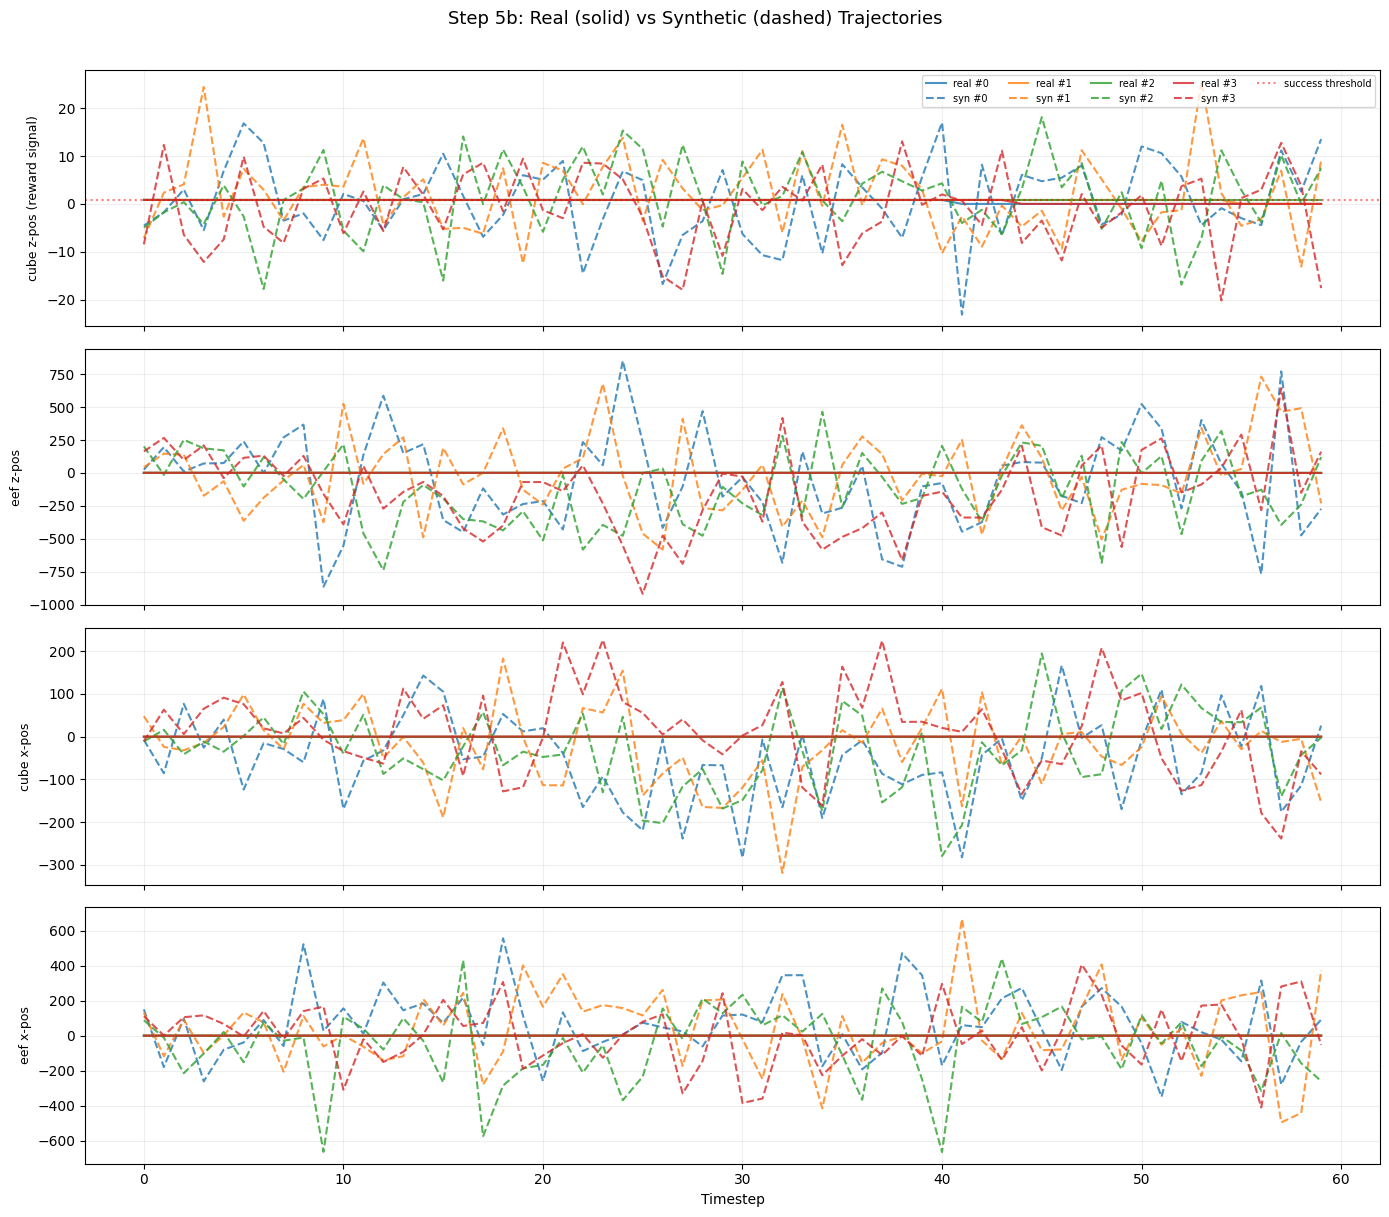

In [16]:
# --- Visual: real vs synthetic trajectories (key dims) ---
key_dims = [
    (2, "cube z-pos (reward signal)"),
    (12, "eef z-pos"),
    (0, "cube x-pos"),
    (10, "eef x-pos"),
]
n_show = min(4, NUM_TRAJS)

fig, axes = plt.subplots(len(key_dims), 1, figsize=(14, 3 * len(key_dims)), sharex=True)
for row, (dim_idx, dim_name) in enumerate(key_dims):
    ax = axes[row]
    for b in range(n_show):
        ax.plot(real_states[b, :, dim_idx], color=f"C{b}", alpha=0.8, linewidth=1.5,
                label=f"real #{b}" if row == 0 else None)
        ax.plot(syn_states[b, :, dim_idx], color=f"C{b}", alpha=0.8, linewidth=1.5,
                linestyle="--", label=f"syn #{b}" if row == 0 else None)
    ax.set_ylabel(dim_name, fontsize=9)
    if dim_idx == 2:
        ax.axhline(0.84, color="red", linestyle=":", alpha=0.5,
                   label="success threshold" if row == 0 else None)
    ax.grid(alpha=0.2)

axes[0].legend(ncol=n_show + 1, fontsize=7, loc="upper right")
axes[-1].set_xlabel("Timestep")
fig.suptitle("Step 5b: Real (solid) vs Synthetic (dashed) Trajectories", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

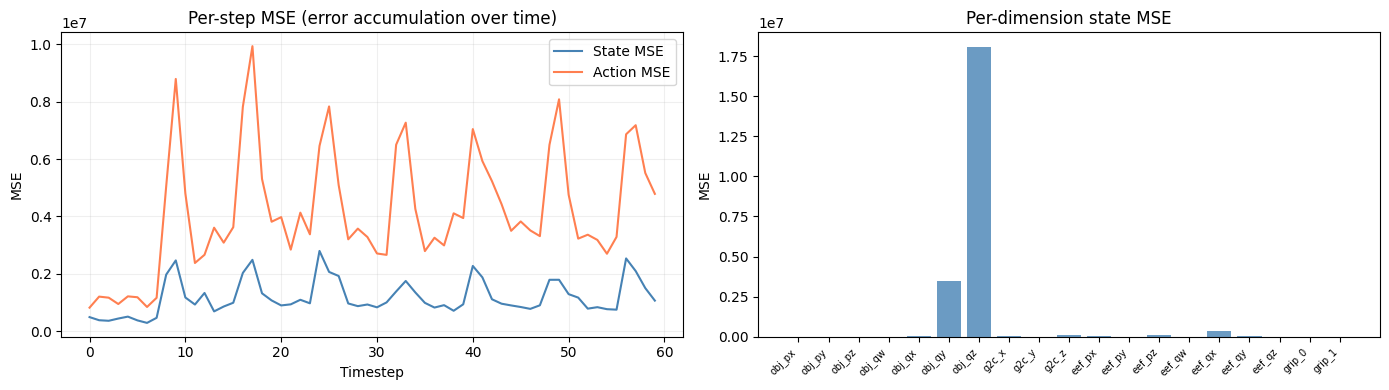

In [17]:
# --- Per-dimension MSE bar chart ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(recon.state_mse_per_step, color="steelblue", linewidth=1.5, label="State MSE")
ax1.plot(recon.action_mse_per_step, color="coral", linewidth=1.5, label="Action MSE")
ax1.set_xlabel("Timestep")
ax1.set_ylabel("MSE")
ax1.set_title("Per-step MSE (error accumulation over time)")
ax1.legend()
ax1.grid(alpha=0.2)

dim_labels = [
    "obj_px", "obj_py", "obj_pz", "obj_qw", "obj_qx", "obj_qy", "obj_qz",
    "g2c_x", "g2c_y", "g2c_z", "eef_px", "eef_py", "eef_pz",
    "eef_qw", "eef_qx", "eef_qy", "eef_qz", "grip_0", "grip_1",
]
ax2.bar(range(len(recon.state_mse_per_dim)), recon.state_mse_per_dim, color="steelblue", alpha=0.8)
ax2.set_xticks(range(len(dim_labels)))
ax2.set_xticklabels(dim_labels, rotation=45, ha="right", fontsize=7)
ax2.set_ylabel("MSE")
ax2.set_title("Per-dimension state MSE")
plt.tight_layout()
plt.show()

In [18]:
# --- Marginal statistics table ---
print(f"\n{'Dim':<10} {'Real mean':>10} {'Syn mean':>10} {'Real std':>10} {'Syn std':>10} {'Real [min,max]':>20} {'Syn [min,max]':>20}")
print("-" * 102)
for d, label in enumerate(dim_labels):
    r, s = real_states[:, :, d], syn_states[:, :, d]
    print(f"{label:<10} {r.mean():10.4f} {s.mean():10.4f} {r.std():10.4f} {s.std():10.4f} "
          f"[{r.min():7.3f}, {r.max():7.3f}]  [{s.min():7.3f}, {s.max():7.3f}]")


Dim         Real mean   Syn mean   Real std    Syn std       Real [min,max]        Syn [min,max]
------------------------------------------------------------------------------------------------------
obj_px         0.0037   -16.5039     0.0162   100.6403 [ -0.028,   0.040]  [-449.395, 314.136]
obj_py         0.0031    11.2962     0.0152    98.5144 [ -0.032,   0.029]  [-341.900, 456.151]
obj_pz         0.7323     0.6066     0.2553     7.8420 [  0.000,   0.835]  [-24.644,  25.525]
obj_qw         0.0014    -6.6485     0.0168    80.9462 [ -0.187,   0.232]  [-302.912, 266.744]
obj_qx         0.0032   -23.7169     0.0326   173.2034 [ -0.171,   0.443]  [-934.832, 634.427]
obj_qy         0.5890  -233.4266     0.3447  1847.9376 [  0.000,   1.000]  [-10800.044, 6499.444]
obj_qz         0.1420  -963.8871     0.6360  4141.4438 [ -0.998,   0.998]  [-17280.176, 14051.198]
g2c_x          0.0168   -27.9483     0.0380   208.6351 [ -0.044,   0.140]  [-868.524, 839.087]
g2c_y          0.0019     1.2534 

Success rate comparison:
  Real trajectories:      0.0%
  Synthetic (unclamped):  100.0%
  Synthetic (clamped):    0.0%


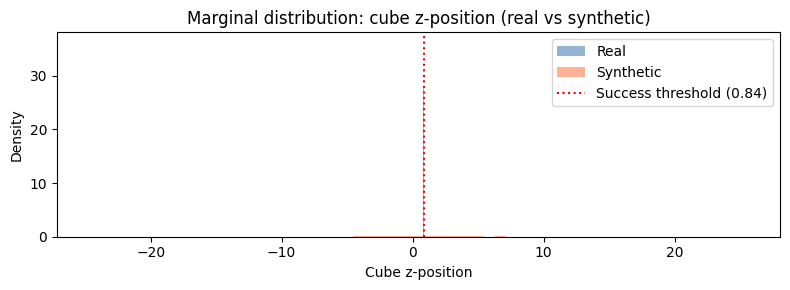

In [19]:
# --- Success rate + cube z histogram ---
print(f"Success rate comparison:")
print(f"  Real trajectories:      {real_success_rate:.1%}")
print(f"  Synthetic (unclamped):  {syn_success_unclamped:.1%}")
print(f"  Synthetic (clamped):    {syn_success_clamped:.1%}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(real_states[:, :, 2].ravel(), bins=60, alpha=0.6, density=True, label="Real", color="steelblue")
ax.hist(syn_states[:, :, 2].ravel(), bins=60, alpha=0.6, density=True, label="Synthetic", color="coral")
ax.axvline(0.84, color="red", linestyle=":", label="Success threshold (0.84)")
ax.set_xlabel("Cube z-position")
ax.set_ylabel("Density")
ax.set_title("Marginal distribution: cube z-position (real vs synthetic)")
ax.legend()
plt.tight_layout()
plt.show()

## Step 7: OPE Evaluation Summary

OPE Evaluation — 50 rollouts, 500 epochs
  Oracle V^pi:           0.540
  OPE estimate:          29.340 (std=3.404)
  OPE clamped estimate:  0.000 (std=0.000)
  Relative error:        5333.33%
  Clamped rel. error:    100.00%


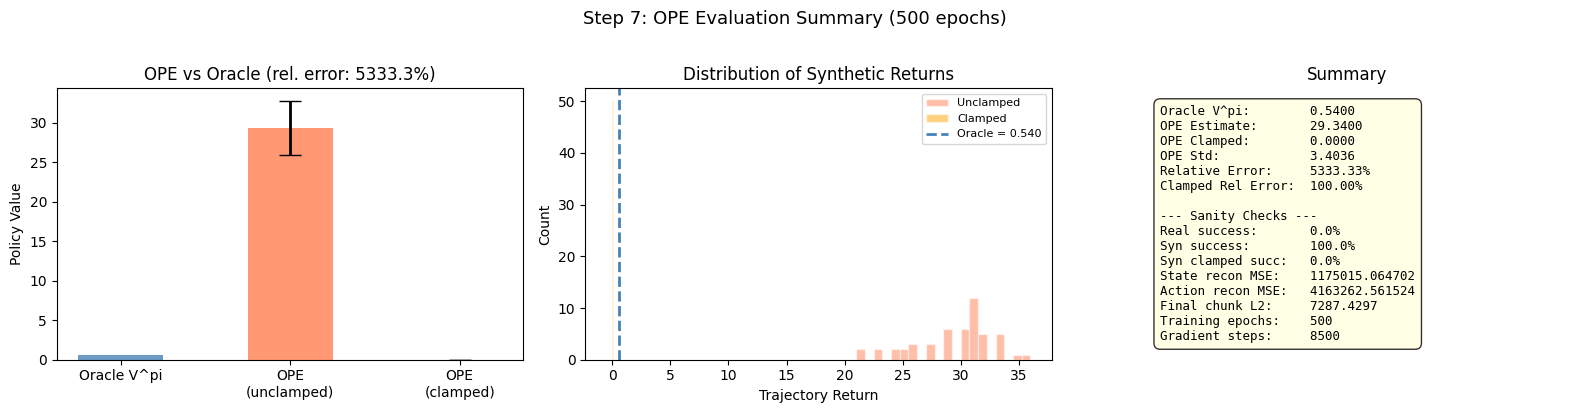

In [20]:
# --- Final OPE summary (3-panel figure) ---
result = ope_unclamped  # Use unclamped as the main result

print("=" * 60)
print("OPE Evaluation — 50 rollouts, 500 epochs")
print("=" * 60)
print(f"  Oracle V^pi:           {result.oracle_value:.3f}")
print(f"  OPE estimate:          {result.ope_estimate:.3f} (std={result.ope_std:.3f})")
print(f"  OPE clamped estimate:  {ope_clamped.ope_estimate:.3f} (std={ope_clamped.ope_std:.3f})")
print(f"  Relative error:        {result.relative_error:.2%}")
print(f"  Clamped rel. error:    {ope_clamped.relative_error:.2%}")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Oracle vs OPE bar chart (unclamped + clamped)
ax = axes[0]
bars = ax.bar(
    ["Oracle V^pi", "OPE\n(unclamped)", "OPE\n(clamped)"],
    [result.oracle_value, result.ope_estimate, ope_clamped.ope_estimate],
    color=["steelblue", "coral", "orange"], alpha=0.8, width=0.5,
)
ax.errorbar(1, result.ope_estimate, yerr=result.ope_std, fmt="none", color="black", capsize=8, linewidth=2)
ax.errorbar(2, ope_clamped.ope_estimate, yerr=ope_clamped.ope_std, fmt="none", color="black", capsize=8, linewidth=2)
ax.set_ylabel("Policy Value")
ax.set_title(f"OPE vs Oracle (rel. error: {result.relative_error:.1%})")

# 2. Distribution of synthetic returns
ax = axes[1]
ax.hist(returns_unclamped, bins=20, alpha=0.5, color="coral", edgecolor="white", label="Unclamped")
ax.hist(returns_clamped, bins=20, alpha=0.5, color="orange", edgecolor="white", label="Clamped")
ax.axvline(result.oracle_value, color="steelblue", linewidth=2, linestyle="--", label=f"Oracle = {result.oracle_value:.3f}")
ax.set_xlabel("Trajectory Return")
ax.set_ylabel("Count")
ax.set_title("Distribution of Synthetic Returns")
ax.legend(fontsize=8)

# 3. Summary text
ax = axes[2]
ax.axis("off")
summary = (
    f"Oracle V^pi:        {result.oracle_value:.4f}\n"
    f"OPE Estimate:       {result.ope_estimate:.4f}\n"
    f"OPE Clamped:        {ope_clamped.ope_estimate:.4f}\n"
    f"OPE Std:            {result.ope_std:.4f}\n"
    f"Relative Error:     {result.relative_error:.2%}\n"
    f"Clamped Rel Error:  {ope_clamped.relative_error:.2%}\n"
    f"\n--- Sanity Checks ---\n"
    f"Real success:       {real_success_rate:.1%}\n"
    f"Syn success:        {syn_success_unclamped:.1%}\n"
    f"Syn clamped succ:   {syn_success_clamped:.1%}\n"
    f"State recon MSE:    {recon.state_mse:.6f}\n"
    f"Action recon MSE:   {recon.action_mse:.6f}\n"
    f"Final chunk L2:     {final_l2:.4f}\n"
    f"Training epochs:    {EPOCHS}\n"
    f"Gradient steps:     {len(all_losses)}"
)
ax.text(0.1, 0.5, summary, transform=ax.transAxes, fontsize=9,
        verticalalignment="center", fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.8))
ax.set_title("Summary")

fig.suptitle("Step 7: OPE Evaluation Summary (500 epochs)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Conclusions & Next Steps

Fill in after running:

**Phase 1 (Training):**
- Did the loss converge? (check loss curve)
- How much did chunk L2 improve vs Mar 9? (check Phase 2.2)

**Phase 2 (Chunk Quality):**
- Is chunk L2 < 1.0? If not, need more training or architectural changes.

**Phase 3 (Diagnostics):**
- Is normalization round-trip clean? (Phase 3.1)
- Does per-step MSE show exponential growth? (Phase 3.2)
- Does clamping help OPE? (Phase 3.3)

**If chunk L2 is still high after 500 epochs:**
- Try with-replacement sampling (5000 steps/epoch like SOPE) — needs code change in training loop
- Try larger model (dim_mults=(1, 4, 8) like SOPE reference)
- Try reducing diffusion steps to 64 (requires retraining)

**If chunk L2 is good but stitching blows up:**
- Implement per-step clamping *during* stitching (not just post-hoc)
- Try Phase 4.1 (post-hoc quaternion normalization)
- Consider reducing horizon or increasing chunk size to need fewer stitching steps